In [2]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Accessing AlternativeMe's Cryptocurrency Fear and Greed Index API

Our data source for Cryptocurrency Fear and Greed Index is AlternativeMe, which also acted as the data source for one of the literature papers we reviewed (Lee, Y. H., Chiu, Y. F., & Hsieh, M. H. (2025)). 

In [3]:
url = "https://api.alternative.me/fng/"
params = {
    "limit": 0,        # 0 = all available historical data
    "format": "json"   # ensure JSON output
}

response = requests.get(url, params = params)
response.raise_for_status() 

data_json = response.json()

In [4]:
df = pd.DataFrame(data_json["data"])
df

,value,value_classification,timestamp,time_until_update
0,11,Extreme Fear,1775260800,40102
1,9,Extreme Fear,1775174400,NaN
2,12,Extreme Fear,1775088000,NaN
3,8,Extreme Fear,1775001600,NaN
4,11,Extreme Fear,1774915200,NaN
...,...,...,...,...
2976,11,Extreme Fear,1517788800,NaN
2977,24,Extreme Fear,1517702400,NaN
2978,40,Fear,1517616000,NaN
2979,15,Extreme Fear,1517529600,NaN


## Data Quality Checks and Cleaning

The columns are all objects. We want `value` to be in integer form, and `timestamp` (currently in Unix format) to be in datetime format. We will make the relevant data type conversions later.

In [5]:
df.dtypes

value                   object
value_classification    object
timestamp               object
time_until_update       object
dtype: object

The `time_until_update` column contains NaN values except for one observation (corresponding to the latest entry in the dataset). A possible interpretation of the number is this column is the number of seconds till the dataset is updated with the next entry (next day's Fear and Greed Index value). It is not very useful for our project so we will drop this column later on. 

In [6]:
df["time_until_update"].value_counts(dropna = False)

time_until_update
NaN      2980
40102       1
Name: count, dtype: int64

In [7]:
df["timestamp"] = df["timestamp"] = pd.to_datetime(pd.to_numeric(df["timestamp"]), unit = "s", utc = True) ## convert Unix timestamps to datetime
df = df.sort_values(by = "timestamp") ## dataset is currently in descending order of date, rearrange to ascending order of date
df = df.drop(columns = ["time_until_update"]).reset_index(drop = True) ## drop the time_until_update column
df["value"] = df["value"].astype(int) ## convert value column to integer type
df

,value,value_classification,timestamp
0,30,Fear,2018-02-01 00:00:00+00:00
1,15,Extreme Fear,2018-02-02 00:00:00+00:00
2,40,Fear,2018-02-03 00:00:00+00:00
3,24,Extreme Fear,2018-02-04 00:00:00+00:00
4,11,Extreme Fear,2018-02-05 00:00:00+00:00
...,...,...,...
2976,11,Extreme Fear,2026-03-31 00:00:00+00:00
2977,8,Extreme Fear,2026-04-01 00:00:00+00:00
2978,12,Extreme Fear,2026-04-02 00:00:00+00:00
2979,9,Extreme Fear,2026-04-03 00:00:00+00:00


Fortunately, for the remaining dataset columns that we will use, there are no missing values.

In [8]:
df.isnull().any()

value                   False
value_classification    False
timestamp               False
dtype: bool

There are 5 categories in the `value_classification` column - Extreme Fear, Fear, Neutral, Greed and Extreme Greed. There are no naming inconsistencies or formatting issues with the categories. We will convert it into a categorical column. 

In [9]:
df["value_classification"].value_counts()

value_classification
Fear             844
Greed            790
Extreme Fear     674
Neutral          392
Extreme Greed    281
Name: count, dtype: int64

In [10]:
df["value_classification"] = df["value_classification"].astype(pd.CategoricalDtype(categories = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"], ordered = True))

Based on the descriptions from AlternativeMe, the `value` column reflects the fear and greed levels on a particular `timestamp`. It is an indicator for the general sentiment towards cryptocurrency at that time. The Fear and Greed index values are between 0 and 100, where a value of 0 means Extreme Fear while a value of 100 means Extreme Greed. 

This means that the 5 Fear and Greed Index categories (Extreme Fear, Fear, Neutral, Greed and Extreme Greed) should be distinct and we should not expect to see much overlap between any two categories ie a Fear and Greed Index value of 10 should only fall in 1 category (Extreme Fear) instead of multiple categories. 

We will now check if the binning of index values in the `value_classification` column is appropriate or not. 

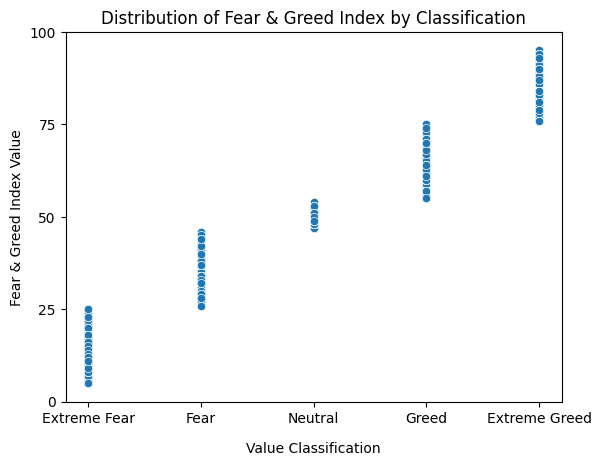

In [11]:
plt.figure()
sns.scatterplot(x="value_classification", y="value", data=df)

plt.xlabel("Value Classification", labelpad = 12)
plt.ylabel("Fear & Greed Index Value")
plt.title("Distribution of Fear & Greed Index by Classification")
plt.yticks([0, 25, 50, 75, 100])

plt.show()

From the scatter plot, we see that indeed, the categories are well-separated. The `value_classification` column's binning is appropriate. 

Lastly, we will verify that the `value` column values are bounded between 0 and 100. 

In [12]:
df["value"].describe()

count    2981.000000
mean       46.251929
std        22.039895
min         5.000000
25%        27.000000
50%        45.000000
75%        65.000000
max        95.000000
Name: value, dtype: float64

Indeed, the lowest `value` recorded was 5 (Extreme Fear) and the highest recorded was 95 (Extreme Greed). 

Overall, the data is clean and does not need any further cleaning. We will subset it to keep the data for the date range we are interested in.

In [13]:
start_date = pd.to_datetime("2020-11-25", utc = True) ## standardized to the start date of cleaned_ustc.csv
end_date = pd.to_datetime("2026-03-19", utc = True) ## standardized to the end date of cleaned_ustc.csv

df = df[(df["timestamp"] >= start_date) & (df["timestamp"] <= end_date)].reset_index(drop = True)
df = df.rename(columns = {"timestamp": "date"})
df

,value,value_classification,date
0,94,Extreme Greed,2020-11-25 00:00:00+00:00
1,93,Extreme Greed,2020-11-26 00:00:00+00:00
2,86,Extreme Greed,2020-11-27 00:00:00+00:00
3,87,Extreme Greed,2020-11-28 00:00:00+00:00
4,89,Extreme Greed,2020-11-29 00:00:00+00:00
...,...,...,...
1935,15,Extreme Fear,2026-03-15 00:00:00+00:00
1936,23,Extreme Fear,2026-03-16 00:00:00+00:00
1937,28,Fear,2026-03-17 00:00:00+00:00
1938,26,Fear,2026-03-18 00:00:00+00:00


The chart below shows that in the pre-crash period, there was a decline in the Crypto Fear & Greed Index, signalling fear as the general sentiment among cryptocurrency investors leading up to the stablecoin crash. 

In [14]:
crash_start = pd.to_datetime("2022-05-09", utc = True) ## crash_start date defined in cleaned_ustc.ipynb
pre_crash_start = pd.to_datetime("2022-05-02", utc = True) ## pre_crash_start date defined in cleaned_ustc.ipynb
crash_end = pd.to_datetime("2023-01-31", utc = True) ## crash_end date defined in cleaned_ustc.ipynb
post_crash_end = pd.to_datetime("2023-02-07", utc = True) ## post_crash_end date defined in cleaned_ustc.ipynb

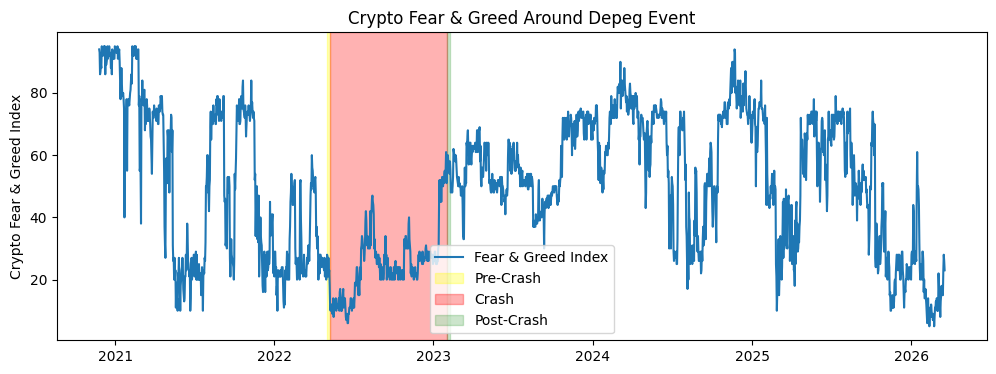

In [15]:
plt.figure(figsize=(12,4))
plt.plot(df["date"], df["value"], label = "Fear & Greed Index")
plt.axvspan(pre_crash_start, crash_start, color = 'yellow', alpha = 0.3, label = "Pre-Crash")
plt.axvspan(crash_start, crash_end, color = 'red', alpha = 0.3, label = "Crash")
plt.axvspan(crash_end, post_crash_end, color = 'green', alpha = 0.2, label = "Post-Crash")

plt.title("Crypto Fear & Greed Around Depeg Event")
plt.ylabel("Crypto Fear & Greed Index")
plt.legend()
plt.show()

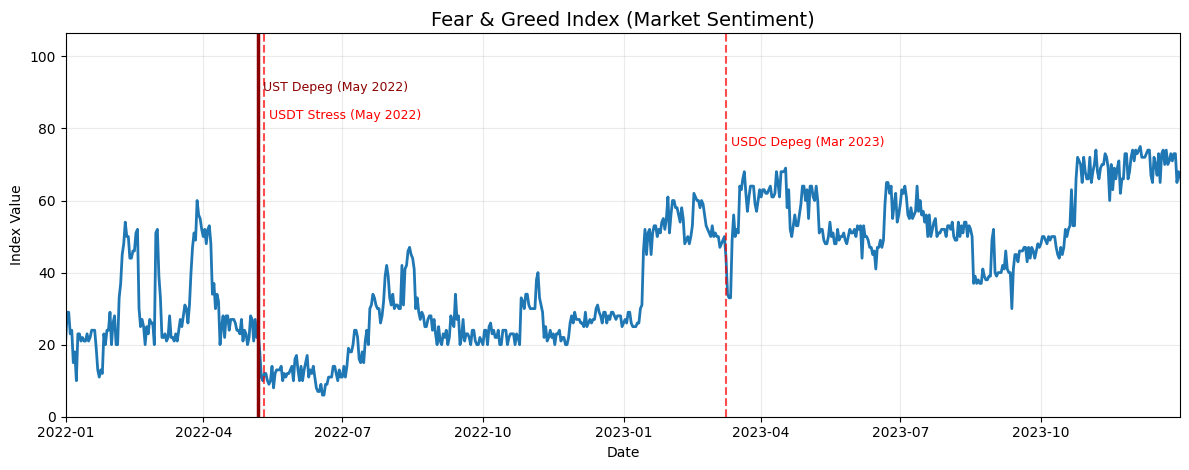

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# make sure date column is datetime
df["date"] = pd.to_datetime(df["date"])

# major event dates
event_dates = {
    "UST Depeg (May 2022)": "2022-05-07",
    "USDT Stress (May 2022)": "2022-05-11",
    "USDC Depeg (Mar 2023)": "2023-03-09"
}

plt.style.use("default")
plt.figure(figsize=(12, 4.8))

# main line
plt.plot(
    df["date"],
    df["value"],
    linewidth=2,
    label="Fear & Greed Index"
)

# get max y for label placement
y_max = df["value"].max()

y_positions = [0.98, 0.90, 0.82]

for (label, date), y_pos in zip(event_dates.items(), y_positions):
    date = pd.to_datetime(date)

    if "UST" in label:
        plt.axvline(date, color="darkred", linewidth=2.5)
    else:
        plt.axvline(date, color="red", linestyle="--", linewidth=1.5, alpha=0.7)

    plt.text(
        date + pd.Timedelta(days=3),
        y_max * y_pos,
        label,
        fontsize=9,
        color="darkred" if "UST" in label else "red",
        ha="left",
        va="top"
    )

# focus on relevant period
plt.xlim(pd.to_datetime("2022-01-01"), pd.to_datetime("2023-12-31"))
plt.ylim(0, y_max * 1.12)

# labels and title
# labels and title
plt.title("Fear & Greed Index (Market Sentiment)", fontsize=14)
plt.ylabel("Index Value")
plt.xlabel("Date")

# clean up
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Exporting Cleaned Dataset

In [ ]:
#df.to_csv("../raw_data/fear_greed_index.csv", index = False)